In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print("Tools are ready!")

Tools are ready!


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
df=pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price']=housing.target

print(f'There are {len(df)} houses in the list.')
print(df.head())

There are 20640 houses in the list.
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [ ]:
#X=income, y=price
X=df[['MedInc']]
y=df['Price']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Data split successfully!')
print(f'Training set size: {len(X_train)}')
print(f'Testing set size: {len(X_test)}')

Data split successfully!
Training set size: 16512
Testing set size: 4128


In [ ]:
from sklearn.preprocessing import StandardScaler

#scale the data
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print('Data scaled successfully!')

Data scaled successfully!


In [ ]:
#Training on training set
model=LinearRegression()
model.fit(X_train, y_train)
print('Model trained on training set.')

Model trained on training set.


In [ ]:
#Test
predictions=model.predict(X_test)

print('Guesses vs Actual: ')

for i in range(5):
  print(f'Guess: {predictions[i]:.2f} | Actual: {y_test.values[i]:.2f}')


Guesses vs Actual: 
Guess: 1.15 | Actual: 0.48
Guess: 1.51 | Actual: 0.46
Guess: 1.90 | Actual: 5.00
Guess: 2.85 | Actual: 2.19
Guess: 2.01 | Actual: 2.78


In [ ]:
from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_test, predictions)
print(f'Mean Absolute Error: {mae:.2f}')

Mean Absolute Error: 0.63


In [ ]:
print(f'Avg house price: ${df['Price'].mean()*100000:,.2f}')

Avg house price: $206,855.82


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
#including new features
X=df.drop('Price', axis=1) #use every column except price
y=df['Price']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train the simple linear regression
lr_model=LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions=lr_model.predict(X_test)
lr_mae=mean_absolute_error(y_test, lr_predictions)
print(f'Mean Absolute Error of linear regression (All features): {lr_mae:.2f}')


Mean Absolute Error of linear regression (All features): 0.53


In [ ]:
#train the random forest
rf_model= RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions=rf_model.predict(X_test)
rf_mae=mean_absolute_error(y_test, rf_predictions)
print(f'Mean Absolute Error of random forest (All features): {rf_mae:.2f}')

Mean Absolute Error of random forest (All features): 0.33


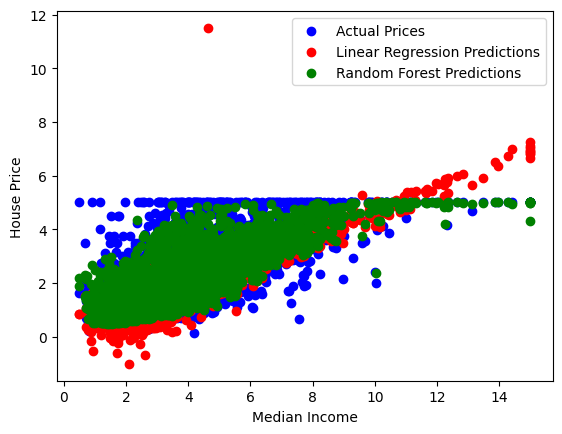

In [ ]:
plt.scatter(X_test['MedInc'], y_test, color='blue', label='Actual Prices')
plt.scatter(X_test['MedInc'], lr_predictions, color='red', label='Linear Regression Predictions')
plt.scatter(X_test['MedInc'], rf_predictions, color='green', label='Random Forest Predictions')
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.legend()
plt.show()

In [ ]:
#feature selection
X_simple=df.drop(['Price', 'Latitude', 'Longitude'], axis=1)

print('Remaining features: ', X_simple.columns.tolist())

Remaining features:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']


In [ ]:
X_trainsimple, X_testsimple, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

lr_simple_model=LinearRegression()
lr_simple_model.fit(X_trainsimple, y_train)
lr_simple_predictions=lr_simple_model.predict(X_testsimple)
lr_simple_mae=mean_absolute_error(y_test, lr_simple_predictions)
print(f'Mean Absolute Error of linear regression (Simple features): {lr_simple_mae:.2f}')

Mean Absolute Error of linear regression (Simple features): 0.58


In [ ]:
import numpy as np

errors=abs(rf_predictions - y_test)
relative_error=(errors/y_test)*100
accuracy=100-np.mean(relative_error)

print(f'Random forest accuracy: {accuracy:.2f}%')

Random forest accuracy: 81.08%


In [ ]:
comparison_df=pd.DataFrame({'Actual':y_test,'Predicted':rf_predictions})

print(comparison_df.head(10))

        Actual  Predicted
20046  0.47700   0.509500
3024   0.45800   0.741610
15663  5.00001   4.923257
20484  2.18600   2.529610
9814   2.78000   2.273690
13311  1.58700   1.646920
7113   1.98200   2.376050
7668   1.57500   1.669320
18246  3.40000   2.772971
5723   4.46600   4.913459


In [ ]:
rich_house=X_test.head(1).copy()
rich_house['MedInc']=15.0

poor_house=X_test.head(1).copy()
poor_house['MedInc']=2.0

rich_price=rf_model.predict(rich_house)
poor_price=rf_model.predict(poor_house)

print(f'Rich house price: ${rich_price[0]*100000:,.0f}')
print(f'Poor house price: ${poor_price[0]*100000:,.0f}')

Rich house price: $420,513
Poor house price: $55,085


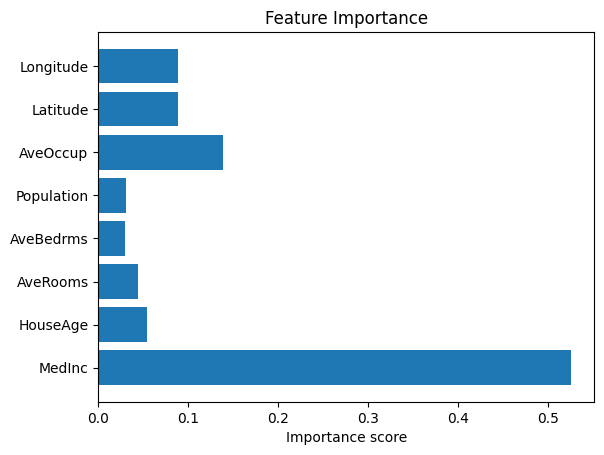

In [ ]:
#get importance of each feature

importances=rf_model.feature_importances_
feature_names=X.columns

plt.barh(feature_names, importances)
plt.xlabel('Importance score')
plt.title('Feature Importance')
plt.show()

In [ ]:
#test the model
richhouse2=X_test.head(1).copy()
richhouse2['MedInc']=23.0

poorhouse2=X_test.head(1).copy()
poorhouse2['MedInc']=0.5

richprice2=rf_model.predict(richhouse2)
poorprice2=rf_model.predict(poorhouse2)

print(f'Rich house price: ${richprice2[0]*100000:,.0f}')
print(f'Poor house price: ${poorprice2[0]*100000:,.0f}')

Rich house price: $420,513
Poor house price: $67,741
